✅ Analyse du dernier test généré : Test_105_triad_20260420_1449.csv


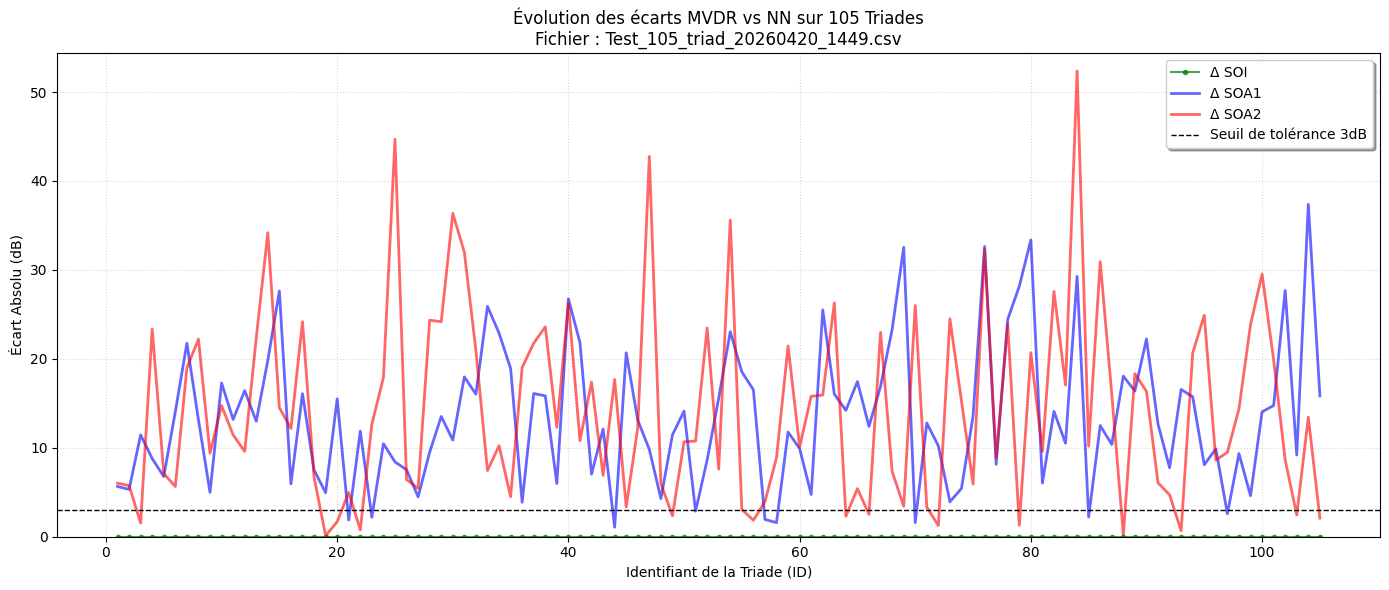


--- STATISTIQUES D'ERREUR MOYENNE (dB) ---
Dt_MV_NN_SOI      0.000
Dt_MV_NN_SOA1    13.439
Dt_MV_NN_SOA2    14.451
dtype: float64
------------------------------------------


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# --- 1. CONFIGURATION DU CHEMIN ---
# On cible le dossier où tu sauvegardes tes tests
folder_path = "../FFNN_tests/"
# On cherche tous les fichiers CSV commençant par "Test_105_triad_"
search_pattern = os.path.join(folder_path, "Test_105_triad_*.csv")

# --- 2. RECHERCHE DU FICHIER LE PLUS RÉCENT ---
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    print(f"❌ Aucun fichier trouvé dans {folder_path} avec le pattern spécifié.")
else:
    # On trie par date de création (ctime) pour prendre le dernier
    latest_file = max(list_of_files, key=os.path.getctime)
    print(f"✅ Analyse du dernier test généré : {os.path.basename(latest_file)}")

    # --- 3. CHARGEMENT DES DONNÉES ---
    # Rappel : sep=';' car c'est ce que tu as utilisé dans ton script de génération
    df = pd.read_csv(latest_file, sep=';')

    # --- 4. GÉNÉRATION DES COURBES D'ÉCART (DELTAS) ---
    plt.figure(figsize=(14, 6))

    # Tracé des erreurs pour le SOI et les deux interférences (SOA)
    # On utilise des marqueurs pour bien distinguer les 105 points
    plt.plot(df['ID'], df['Dt_MV_NN_SOI'], label='Δ SOI ', color='green', alpha=0.7, marker='.')
    plt.plot(df['ID'], df['Dt_MV_NN_SOA1'], label='Δ SOA1 ', color='blue', alpha=0.6, linewidth=2)
    plt.plot(df['ID'], df['Dt_MV_NN_SOA2'], label='Δ SOA2 ', color='red', alpha=0.6, linewidth=2)

    # Ajout d'une ligne de seuil à 3dB (seuil souvent utilisé en ingénierie)
    plt.axhline(y=3, color='black', linestyle='--', linewidth=1, label='Seuil de tolérance 3dB')

    # --- 5. MISE EN FORME ---
    plt.title(f"Évolution des écarts MVDR vs NN sur 105 Triades\nFichier : {os.path.basename(latest_file)}", fontsize=12)
    plt.xlabel("Identifiant de la Triade (ID)", fontsize=10)
    plt.ylabel("Écart Absolu (dB)", fontsize=10)
    
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.ylim(0, max(df['Dt_MV_NN_SOA2'].max(), 10) + 2) # Ajuste l'échelle Y automatiquement
    
    plt.tight_layout()
    
    # Sauvegarde optionnelle du graphique
    # plt.savefig(f"Analyse_Deltas_{datetime.now().strftime('%H%M')}.png")
    
    plt.show()

    # --- 6. RÉSUMÉ STATISTIQUE ---
    print("\n--- STATISTIQUES D'ERREUR MOYENNE (dB) ---")
    stats = df[['Dt_MV_NN_SOI', 'Dt_MV_NN_SOA1', 'Dt_MV_NN_SOA2']].mean()
    print(stats.round(3))
    print("------------------------------------------")